# USO DE GRIDSEARCHCV


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic_df = sns.load_dataset('titanic')
titanic_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


# EDA

In [3]:
columns_to_drop = ['fare','embarked','class','who','adult_male','deck','embark_town','alive','alone']
titanic_df.drop(columns_to_drop,axis='columns',inplace=True)
titanic_df

,survived,pclass,sex,age,sibsp,parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
886,0,2,male,27.0,0,0
887,1,1,female,19.0,0,0
888,0,3,female,NaN,1,2
889,1,1,male,26.0,0,0


# ANALIZAMOS NULOS

In [4]:
titanic_df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0


In [ ]:
titanic_df.dropna(inplace=True)

In [5]:
titanic_df

,survived,pclass,sex,age,sibsp,parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
886,0,2,male,27.0,0,0
887,1,1,female,19.0,0,0
888,0,3,female,NaN,1,2
889,1,1,male,26.0,0,0


# CODIFICACIÓN DE VARIABLES CATEGORICAS

In [6]:
titanic_df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64


In [7]:
titanic_df = pd.get_dummies(titanic_df,columns=['sex'],drop_first=True)
titanic_df.head()

,survived,pclass,age,sibsp,parch,sex_male
0,0,3,22.0,1,0,True
1,1,1,38.0,1,0,False
2,1,3,26.0,0,0,False
3,1,1,35.0,1,0,False
4,0,3,35.0,0,0,True


In [8]:
titanic_df['sex_male'] = titanic_df['sex_male'].astype(int)
titanic_df.rename(columns = {'sex_male':'sex'},inplace=True)
titanic_df.head(10)

,survived,pclass,age,sibsp,parch,sex
0,0,3,22.0,1,0,1
1,1,1,38.0,1,0,0
2,1,3,26.0,0,0,0
3,1,1,35.0,1,0,0
4,0,3,35.0,0,0,1
5,0,3,NaN,0,0,1
6,0,1,54.0,0,0,1
7,0,3,2.0,3,1,1
8,1,3,27.0,0,2,0
9,1,2,14.0,1,0,0


# DIVISION DE DATASET EN ENTRENAMIENTO Y PRUEBA

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = titanic_df.drop('survived',axis=1)
y = titanic_df['survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=00000)

# EVALUANDO LA MEJOR COMBINACIÓN DE PARAMETROS CON GRIDSEARCHCV

In [10]:
from sklearn.model_selection import GridSearchCV

## DEFINIR VARIOS PARAMETROS

In [11]:
param_grid = {
    'max_depth': [3,4,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'criterion':['gini','entropy']
}

## CREAMOS EL MODELO

In [12]:
clf = DecisionTreeClassifier(random_state=42)

## APLICAMOS GRIDSEARCHCV

In [13]:
grid_search = GridSearchCV(clf,param_grid,cv=5,scoring='accuracy',n_jobs=1)
grid_search.fit(X_train,y_train)
print(f'Mejor combinación de parámetros: {grid_search.best_params_}')

Mejor combinación de parámetros: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}


# ENTRENAMIENTO DE MODELO CON MEJORES PARAMETROS

In [14]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Exactitud del modelo: {accuracy}')

Exactitud del modelo: 0.8212290502793296


# VERIFICAMOS LAS VARIABLES MAS IMPORTANTES

In [15]:
importances = best_model.feature_importances_
importances

array([0.16483424, 0.13981761, 0.10906073, 0.00522481, 0.58106261])

In [16]:
columns = X.columns
columns

Index(['pclass', 'age', 'sibsp', 'parch', 'sex'], dtype='object')

/tmp/ipython-input-158995257.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columns,y=importances,palette='bright',saturation= 2.0,edgecolor='black',linewidth=2)


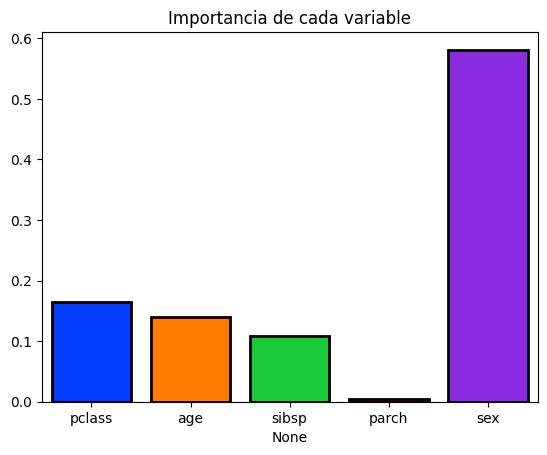

In [17]:
sns.barplot(x=columns,y=importances,palette='bright',saturation= 2.0,edgecolor='black',linewidth=2)
plt.title('Importancia de cada variable')
plt.show()